# National Fatality Forecasting toward Vision 2030
### التنبؤ بوفيات حوادث الطرق حتى رؤية 2030

**Notebook:** `02_forecasting.ipynb`
**Author:** Khalid Al-Dosari ([@khaliddosari](https://github.com/khaliddosari))
**Project:** [saudi-road-safety-mlops](https://github.com/khaliddosari/saudi-road-safety-mlops)

---

## Objectives

Forecast the national road-traffic death rate (per 100k population) from 2024 to 2030 and quantify the gap to Saudi Arabia's Vision 2030 target of **< 10 deaths per 100,000**. Because the publicly released national series is annual and short (n = 10, 2014–2023), the emphasis is on:

1. **Honest diagnostics** — stationarity, structural break, sample-size caveats.
2. **Intervention modeling** — treat 2020 as a **regime shift** (COVID + sustained behavioral / enforcement change), not a pulse.
3. **Multiple model families** for robustness, not bravado:
   - Naive drift (baseline)
   - OLS trend with a COVID step dummy (interpretable)
   - SARIMAX with exogenous COVID dummy (statistical ARIMA family)
   - Prophet with a 2020 changepoint + COVID regressor (piecewise Bayesian)
4. **Walk-forward backtest** on the last 3 years to weight the models empirically.
5. **Weighted ensemble** projection to 2030 with confidence intervals.
6. **Gap analysis** — how far from the Vision 2030 target, and what trajectory is needed.

Forecast tables are saved to `data/processed/national_forecast.csv` for downstream consumption by the FastAPI service and the Power BI dashboard.

> **Caveat on sample size.** Ten annual data points is small for any statistical forecast. The point of this notebook is not to publish a 2030 number as truth; it is to build a **reproducible, MLflow-ready forecasting pipeline** and to frame the 2030 gap in policy-relevant terms. All intervals should be read with the sample size in mind.

In [1]:
from __future__ import annotations

import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from prophet import Prophet
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prophet and cmdstanpy are chatty on annual data; silence them
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
PROCESSED = REPO_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RNG = np.random.default_rng(42)

print("Repo root :", REPO_ROOT)
print("Processed :", PROCESSED)

c:\Users\Khalid\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo root : c:\Users\Khalid\Downloads\Coding Projects\saudi-road-safety-mlops
Processed : c:\Users\Khalid\Downloads\Coding Projects\saudi-road-safety-mlops\data\processed


In [2]:
national = pd.read_csv(PROCESSED / "national_trend.csv").dropna(subset=["year"])
national["year"] = national["year"].astype(int)
national = national.sort_values("year").reset_index(drop=True)

TARGET = "death_rate_per_100k"   # Vision 2030 KPI
SECONDARY = "national_deaths"    # for count-level Power BI view

HORIZON_END = 2030
VISION_TARGET = 10.0             # deaths per 100k by 2030

national["date"] = pd.to_datetime(national["year"].astype(str) + "-01-01")
series = national.set_index("date")[TARGET]

print(f"Series  : {TARGET}")
print(f"Years   : {national['year'].min()} – {national['year'].max()}  (n = {len(national)})")
print(f"Horizon : forecast {national['year'].max() + 1} – {HORIZON_END}  "
      f"({HORIZON_END - national['year'].max()} years ahead)")
national

Series  : death_rate_per_100k
Years   : 2014 – 2023  (n = 10)
Horizon : forecast 2024 – 2030  (7 years ahead)


,year,national_injuries,national_deaths,injury_rate_per_100k,death_rate_per_100k,date
0,2014,"35,843.00","7,486.00",126.61,26.44,2014-01-01
1,2015,"36,302.00","8,063.00",121.75,27.04,2015-01-01
2,2016,"38,120.00","8,759.00",123.15,28.30,2016-01-01
3,2017,"33,199.00","7,218.00",107.17,23.30,2017-01-01
4,2018,"30,217.00","5,787.00",100.07,19.16,2018-01-01
5,2019,"32,910.00","5,754.00",109.47,19.14,2019-01-01
6,2020,"25,561.00","4,618.00",81.01,14.64,2020-01-01
7,2021,"25,512.00","4,652.00",82.87,15.11,2021-01-01
8,2022,"24,446.00","4,555.00",75.98,14.16,2022-01-01
9,2023,"24,002.00","4,423.00",70.87,13.06,2023-01-01


## 1. Series diagnostics | التشخيص الإحصائي للسلسلة

Three things to establish before any modeling:

- **Shape of the decline** — is it a smooth trend or a broken trend with a 2020 regime shift?
- **Stationarity** — can ARIMA-family models be applied in levels, or is differencing needed?
- **Sample-size reality check** — what model complexity can n = 10 actually support?

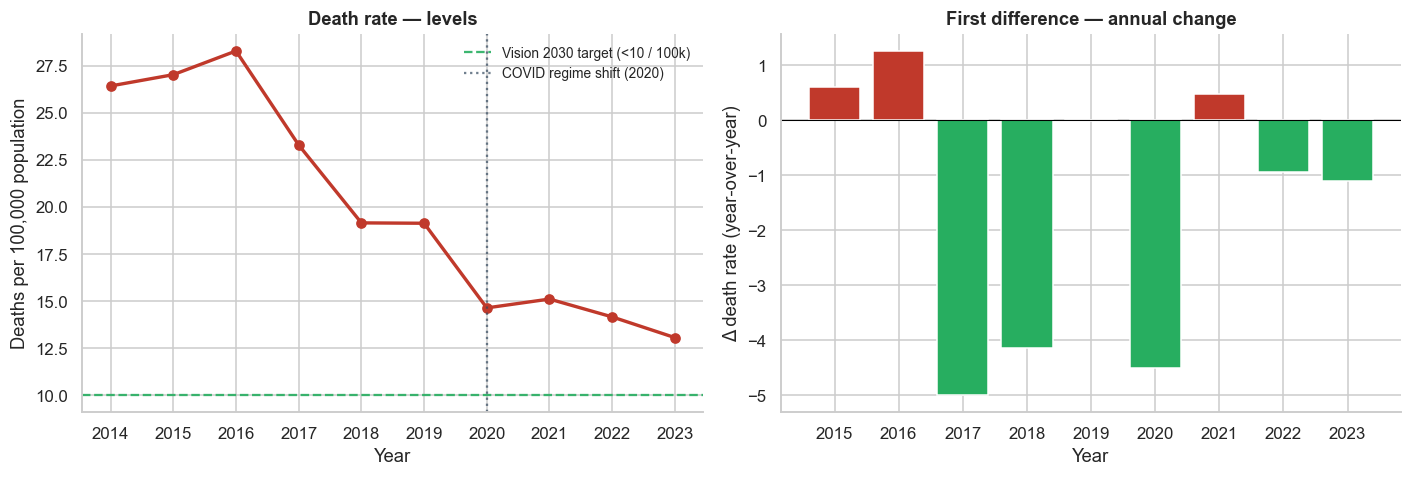

Augmented Dickey-Fuller test:
             series  n  adf_stat  p_value  stationary_at_5%
death_rate (levels) 10     -9.53     0.00              True
    death_rate (Δ1)  9     -3.05     0.03              True

Mean Δ (pre-2020, 2015–2019) : -1.46 per 100k / yr
Mean Δ (post-2020, 2021–2023): -0.53 per 100k / yr
2020 shock                   : -4.50 per 100k / yr


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Levels ------------------------------------------------------------------
ax1.plot(national["year"], national[TARGET], marker="o", lw=2.2, color="#c0392b")
ax1.axhline(VISION_TARGET, ls="--", color="#27ae60", alpha=0.9,
            label=f"Vision 2030 target (<{VISION_TARGET:.0f} / 100k)")
ax1.axvline(2020, ls=":", color="#34495e", alpha=0.7, label="COVID regime shift (2020)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Deaths per 100,000 population")
ax1.set_title("Death rate — levels")
ax1.legend(loc="upper right", frameon=False, fontsize=9)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))

# First difference --------------------------------------------------------
diff = national[TARGET].diff()
ax2.bar(national["year"], diff,
        color=["#27ae60" if v < 0 else "#c0392b" for v in diff.fillna(0)])
ax2.axhline(0, color="black", lw=0.7)
ax2.set_xlabel("Year")
ax2.set_ylabel("Δ death rate (year-over-year)")
ax2.set_title("First difference — annual change")
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.show()

# ADF test on levels and first difference ---------------------------------
def adf_report(x: pd.Series, label: str) -> dict:
    x_ = x.dropna()
    stat, p, *_ = adfuller(x_, autolag="AIC")
    return {"series": label, "n": len(x_), "adf_stat": stat, "p_value": p,
            "stationary_at_5%": p < 0.05}

adf_tbl = pd.DataFrame([
    adf_report(national[TARGET], "death_rate (levels)"),
    adf_report(national[TARGET].diff(), "death_rate (Δ1)"),
])
print("Augmented Dickey-Fuller test:")
print(adf_tbl.to_string(index=False))
print()
print(f"Mean Δ (pre-2020, 2015–2019) : {diff.iloc[1:6].mean():+.2f} per 100k / yr")
print(f"Mean Δ (post-2020, 2021–2023): {diff.iloc[-3:].mean():+.2f} per 100k / yr")
print(f"2020 shock                   : {diff.loc[national['year']==2020].values[0]:+.2f} per 100k / yr")

## 2. Modeling strategy | استراتيجية النمذجة

**Target.** `death_rate_per_100k` — the Vision 2030 KPI. Modeling the rate (rather than the count) absorbs population growth automatically and keeps the target comparable across years.

**Intervention.** The 2020 drop is not a transient pulse — every subsequent year stays well below the pre-2020 trend. We model it as a **step dummy** `covid = 1 if year ≥ 2020 else 0`, which shifts the level once and then lets the post-2020 trend speak for itself. This is fed to SARIMAX as `exog` and to Prophet as an `add_regressor`.

**Complexity budget.** With n = 10 we keep each model small:
- OLS — 3 parameters (intercept, year, covid-step).
- SARIMAX — grid-search `(p, d, q) ∈ {0,1} × {0,1} × {0,1}`, pick lowest AIC.
- Prophet — disable all seasonalities (annual data, no within-year signal here); one changepoint at 2020; covid regressor.

**Validation.** Walk-forward on the last three years (2021, 2022, 2023) — the only way to get an out-of-sample view on a decade-long series without starving the training set.

In [4]:
COVID_START = 2020
FORECAST_YEARS = np.arange(national["year"].max() + 1, HORIZON_END + 1)
HISTORY_YEARS = national["year"].values


def covid_dummy(years: np.ndarray | pd.Series) -> np.ndarray:
    """Step regressor: 1 from 2020 onwards, 0 before."""
    return (np.asarray(years) >= COVID_START).astype(float)


def score(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """Core point-forecast metrics. Returns NaN if y_true is empty."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) == 0:
        return {"mae": np.nan, "rmse": np.nan, "mape": np.nan}
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": float(mean_absolute_percentage_error(y_true, y_pred)) * 100,
    }


# Convenience views used throughout the notebook
hist_df = national[["year", TARGET]].rename(columns={TARGET: "y"}).copy()
hist_df["covid"] = covid_dummy(hist_df["year"])
hist_df.tail()

,year,y,covid
5,2019,19.14,0.00
6,2020,14.64,1.00
7,2021,15.11,1.00
8,2022,14.16,1.00
9,2023,13.06,1.00


## 3. Baselines — naive drift + OLS with intervention

Two baselines to beat:

- **Naive drift** — next value = last value + average historical step. Equivalent to ARIMA(0,1,0) with drift. Ignores the regime shift entirely.
- **OLS with intervention** — a straight line in `year` plus a step indicator for 2020+. The two coefficients on `year` and `covid` are directly interpretable.

NaiveDrift           last=13.06, drift=-1.487/yr
OLS+Intervention     β_year=-1.574/yr, β_covid=-1.78 (level shift), intercept=3197.9


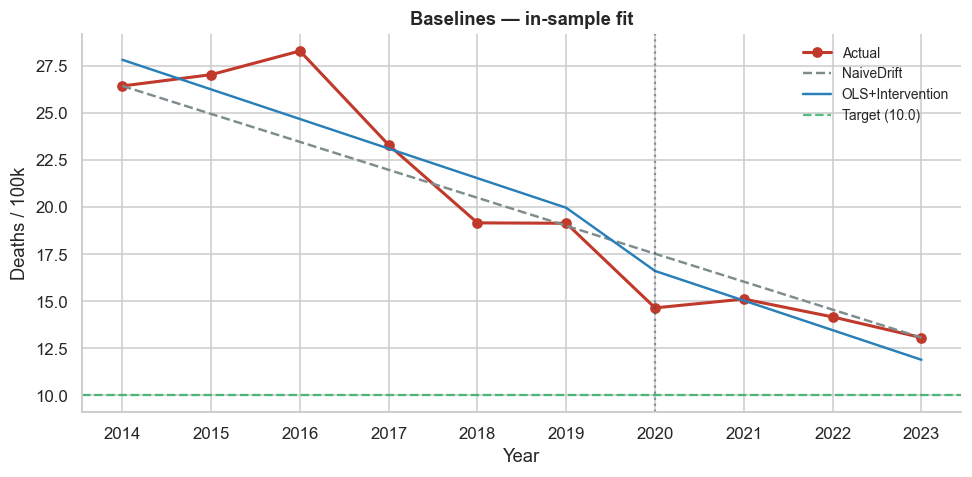

In [5]:
def fit_naive_drift(train: pd.DataFrame) -> dict:
    """train: DataFrame with columns ['year', 'y']. Returns a dict with predict(future_years) -> mean, lower, upper."""
    y = train["y"].values
    drift = (y[-1] - y[0]) / (len(y) - 1)
    last = y[-1]
    resid_std = np.std(np.diff(y), ddof=1)

    def predict(future_years):
        h = np.arange(1, len(future_years) + 1)
        mean = last + drift * h
        # Random-walk variance grows linearly with horizon
        se = resid_std * np.sqrt(h)
        return mean, mean - 1.96 * se, mean + 1.96 * se

    return {"name": "NaiveDrift", "predict": predict,
            "summary": f"last={last:.2f}, drift={drift:+.3f}/yr"}


def fit_ols_intervention(train: pd.DataFrame) -> dict:
    """OLS: y ~ year + covid_step. Confidence band from residual std * sqrt(1 + 1/n) (simple approx)."""
    X = train[["year", "covid"]].values
    y = train["y"].values
    model = LinearRegression().fit(X, y)
    yhat = model.predict(X)
    resid_std = np.std(y - yhat, ddof=max(1, len(y) - X.shape[1] - 1))

    def predict(future_years):
        Xf = np.column_stack([future_years, covid_dummy(future_years)])
        mean = model.predict(Xf)
        se = resid_std * np.sqrt(1 + 1 / len(y))
        return mean, mean - 1.96 * se, mean + 1.96 * se

    beta_year, beta_covid = model.coef_
    return {"name": "OLS+Intervention", "predict": predict, "model": model,
            "summary": f"β_year={beta_year:+.3f}/yr, β_covid={beta_covid:+.2f} (level shift), "
                       f"intercept={model.intercept_:.1f}"}


naive = fit_naive_drift(hist_df)
ols = fit_ols_intervention(hist_df)
print(f"{naive['name']:<20} {naive['summary']}")
print(f"{ols['name']:<20} {ols['summary']}")

# In-sample fit for a quick visual sanity check
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_df["year"], hist_df["y"], "o-", color="#c0392b", lw=2, label="Actual")
for m, color, ls in [(naive, "#7f8c8d", "--"), (ols, "#2980b9", "-")]:
    yrs_fit = np.arange(hist_df["year"].min(), hist_df["year"].max() + 1)
    if m["name"] == "NaiveDrift":
        # drift line through first and last points
        y = hist_df["y"].values
        drift = (y[-1] - y[0]) / (len(y) - 1)
        fit = y[0] + drift * (yrs_fit - yrs_fit[0])
    else:
        fit = m["model"].predict(np.column_stack([yrs_fit, covid_dummy(yrs_fit)]))
    ax.plot(yrs_fit, fit, color=color, ls=ls, lw=1.6, label=m["name"])
ax.axvline(COVID_START, ls=":", color="#34495e", alpha=0.5)
ax.axhline(VISION_TARGET, ls="--", color="#27ae60", alpha=0.8, label=f"Target ({VISION_TARGET})")
ax.set_xlabel("Year")
ax.set_ylabel("Deaths / 100k")
ax.set_title("Baselines — in-sample fit")
ax.legend(frameon=False, fontsize=9)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

## 4. SARIMAX with exogenous COVID dummy | نموذج ساريماكس مع متغير خارجي

Grid-search `(p, d, q) ∈ {0,1} × {0,1} × {0,1}` (excluding the null `(0,0,0)`), select by AIC on the training period, and keep the COVID step dummy as an exogenous regressor. Seasonality is disabled — this is yearly data, no annual sub-cycle.

In [6]:
def fit_sarimax(train: pd.DataFrame, grid=None) -> dict:
    """Grid-search small SARIMAX orders with COVID exogenous regressor; return best by AIC."""
    if grid is None:
        grid = [(p, d, q) for p in (0, 1) for d in (0, 1) for q in (0, 1)
                if (p, d, q) != (0, 0, 0)]

    y = train["y"].values.astype(float)
    exog = train[["covid"]].values.astype(float)

    best = {"aic": np.inf}
    candidates = []
    for order in grid:
        try:
            res = SARIMAX(y, exog=exog, order=order,
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)
            aic = float(res.aic)
            candidates.append({"order": order, "aic": aic})
            if aic < best["aic"]:
                best = {"order": order, "aic": aic, "res": res}
        except Exception as exc:  # noqa: BLE001
            candidates.append({"order": order, "aic": np.nan, "error": str(exc)[:50]})

    res = best["res"]

    def predict(future_years):
        exog_f = covid_dummy(future_years).reshape(-1, 1)
        fc = res.get_forecast(steps=len(future_years), exog=exog_f)
        mean = fc.predicted_mean
        ci = fc.conf_int(alpha=0.05)
        return np.asarray(mean), np.asarray(ci[:, 0]), np.asarray(ci[:, 1])

    return {
        "name": f"SARIMAX{best['order']}",
        "predict": predict,
        "aic": best["aic"],
        "candidates": pd.DataFrame(candidates).sort_values("aic"),
        "summary": f"order={best['order']}, AIC={best['aic']:.2f}",
        "res": res,
    }


sarimax = fit_sarimax(hist_df)
print(f"{sarimax['name']:<20} {sarimax['summary']}")
print("\nGrid search (sorted by AIC):")
print(sarimax["candidates"].to_string(index=False))

SARIMAX(0, 1, 1)     order=(0, 1, 1), AIC=35.52

Grid search (sorted by AIC):
    order   aic
(0, 1, 1) 35.52
(1, 1, 1) 37.49
(1, 0, 1) 40.70
(0, 1, 0) 40.71
(1, 1, 0) 41.68
(1, 0, 0) 43.77
(0, 0, 1) 67.04


## 5. Prophet with 2020 changepoint + COVID regressor | نموذج بروفيت

Prophet is designed for richer calendars, but its piecewise-linear trend with an explicit changepoint at 2020 and the COVID step as an additional regressor gives a third perspective. All seasonalities are turned off — we're feeding it annual data. The `changepoint_prior_scale` is left flexible (0.5) to allow the 2020 break to bend the trend.

In [7]:
def fit_prophet(train: pd.DataFrame) -> dict:
    """Prophet on annual data: no seasonality, manual changepoint at 2020, COVID step as regressor."""
    df = pd.DataFrame({
        "ds": pd.to_datetime(train["year"].astype(str) + "-01-01"),
        "y": train["y"].values,
        "covid": train["covid"].values,
    })
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoints=["2020-01-01"] if (train["year"] >= COVID_START).any() else None,
        changepoint_prior_scale=0.5,
        interval_width=0.95,
    )
    model.add_regressor("covid")
    model.fit(df)

    def predict(future_years):
        future = pd.DataFrame({
            "ds": pd.to_datetime(np.asarray(future_years).astype(str) + "-01-01"),
            "covid": covid_dummy(future_years),
        })
        fc = model.predict(future)
        return (fc["yhat"].values,
                fc["yhat_lower"].values,
                fc["yhat_upper"].values)

    return {"name": "Prophet", "predict": predict, "model": model,
            "summary": "changepoint=2020-01-01, cps_prior=0.5"}


prophet_model = fit_prophet(hist_df)
print(f"{prophet_model['name']:<20} {prophet_model['summary']}")

09:46:54 - cmdstanpy - INFO - Chain [1] start processing
09:46:54 - cmdstanpy - INFO - Chain [1] done processing


Prophet              changepoint=2020-01-01, cps_prior=0.5


## 6. Walk-forward backtest | التحقق المتدحرج

Train on `[2014 … y-1]`, predict year `y`, for `y ∈ {2021, 2022, 2023}`. This is the last three years of the series — the only out-of-sample signal available given n = 10. We use one-step-ahead predictions because the production job will re-fit annually when a new GASTAT yearbook is released.

09:46:55 - cmdstanpy - INFO - Chain [1] start processing
09:46:55 - cmdstanpy - INFO - Chain [1] done processing
09:46:55 - cmdstanpy - INFO - Chain [1] start processing
09:46:55 - cmdstanpy - INFO - Chain [1] done processing
09:46:55 - cmdstanpy - INFO - Chain [1] start processing
09:46:55 - cmdstanpy - INFO - Chain [1] done processing


Per-year backtest:
model        NaiveDrift  OLS+Intervention  Prophet  SARIMAX
cutoff_year                                                
2021              12.67             12.78    12.78    14.64
2022              13.49             12.18    12.18    15.34
2023              12.62             11.25    12.79    13.37

Backtest summary (lower is better):
                  mae  rmse  mape
model                            
SARIMAX          0.66  0.76  4.62
NaiveDrift       1.18  1.48  8.06
Prophet          1.53  1.77 10.51
OLS+Intervention 2.04  2.05 14.43


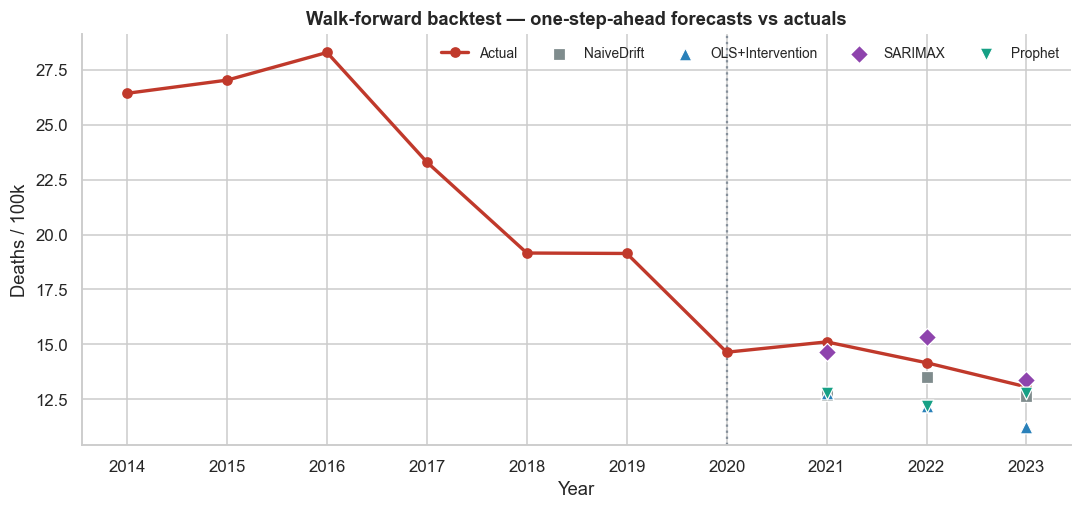

In [8]:
FITTERS = {
    "NaiveDrift": fit_naive_drift,
    "OLS+Intervention": fit_ols_intervention,
    "SARIMAX": fit_sarimax,
    "Prophet": fit_prophet,
}

BACKTEST_YEARS = [2021, 2022, 2023]

records = []
backtest_preds: dict[str, list[tuple[int, float]]] = {name: [] for name in FITTERS}

for cutoff in BACKTEST_YEARS:
    train = hist_df[hist_df["year"] < cutoff].copy()
    actual = hist_df.loc[hist_df["year"] == cutoff, "y"].squeeze()
    for name, fitter in FITTERS.items():
        m = fitter(train)
        mean, lo, hi = m["predict"](np.array([cutoff]))
        yhat = float(mean[0])
        backtest_preds[name].append((cutoff, yhat))
        records.append({
            "model": name,
            "cutoff_year": cutoff,
            "actual": float(actual),
            "forecast": yhat,
            "abs_error": abs(yhat - float(actual)),
        })

bt_df = pd.DataFrame(records)
bt_summary = (bt_df.groupby("model")
              .apply(lambda g: pd.Series(score(g["actual"], g["forecast"])),
                     include_groups=False)
              .round(3)
              .sort_values("mae"))

print("Per-year backtest:")
print(bt_df.pivot(index="cutoff_year", columns="model",
                  values="forecast").round(2).to_string())
print()
print("Backtest summary (lower is better):")
print(bt_summary.to_string())

# Visualize backtest
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(hist_df["year"], hist_df["y"], "o-", color="#c0392b", lw=2.2, label="Actual", zorder=3)
colors = {"NaiveDrift": "#7f8c8d", "OLS+Intervention": "#2980b9",
          "SARIMAX": "#8e44ad", "Prophet": "#16a085"}
markers = {"NaiveDrift": "s", "OLS+Intervention": "^",
           "SARIMAX": "D", "Prophet": "v"}
for name, preds in backtest_preds.items():
    yrs, vals = zip(*preds)
    ax.scatter(yrs, vals, color=colors[name], marker=markers[name], s=70,
               label=name, zorder=4, edgecolor="white", linewidth=0.8)
ax.axvline(COVID_START, ls=":", color="#34495e", alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Deaths / 100k")
ax.set_title("Walk-forward backtest — one-step-ahead forecasts vs actuals")
ax.legend(frameon=False, fontsize=9, ncol=5, loc="upper right")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

## 7. Ensemble forecast to 2030 + Vision 2030 gap | التنبؤ المجمع

Refit every model on the **full** history (2014 – 2023) and project 2024 – 2030. Build a weighted ensemble using **inverse-MAE weights from the backtest** — giving more influence to models that were more accurate in the held-out years. Then compare the 2030 mean to the Vision 2030 target of 10 / 100k.

09:46:55 - cmdstanpy - INFO - Chain [1] start processing
09:46:55 - cmdstanpy - INFO - Chain [1] done processing


Ensemble weights (inverse-MAE, normalized):
model
SARIMAX            0.43
NaiveDrift         0.24
Prophet            0.19
OLS+Intervention   0.14


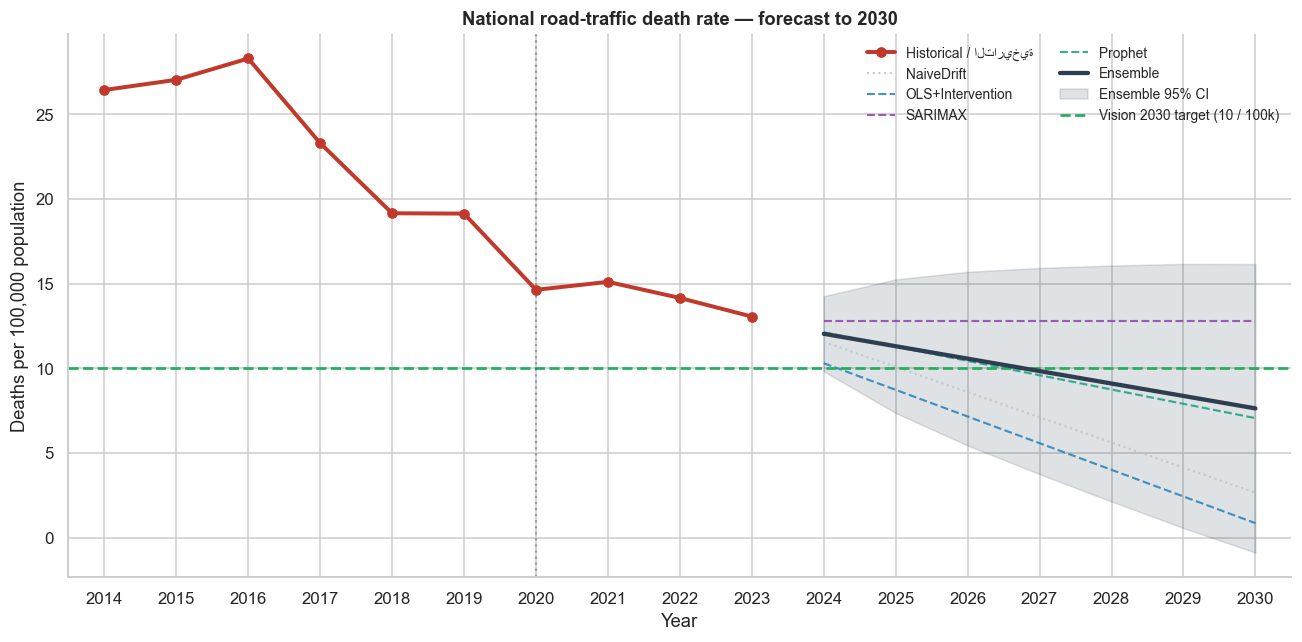


2030 forecast — gap vs Vision 2030 target (10.0):
           model  year  forecast  lower  upper  gap_vs_target  meets_target
OLS+Intervention  2030      0.86  -5.39   7.11          -9.14          True
      NaiveDrift  2030      2.65  -9.89  15.19          -7.35          True
         Prophet  2030      7.06  -3.42  19.39          -2.94          True
        Ensemble  2030      7.64  -0.88  16.16          -2.36          True
         SARIMAX  2030     12.83  -4.75  30.40           2.83         False

Ensemble 2030: 7.6 / 100k  (95% CI -0.9 – 16.2)
Gap vs target: -2.4 / 100k
P(rate < 10 | ensemble) ≈ 70.7%  (normal approx from 95% CI)


In [9]:
final_models = {name: fitter(hist_df) for name, fitter in FITTERS.items()}

# Per-model 2024-2030 forecasts
forecast_rows = []
for name, m in final_models.items():
    mean, lo, hi = m["predict"](FORECAST_YEARS)
    for yr, mu, l, h in zip(FORECAST_YEARS, mean, lo, hi):
        forecast_rows.append({"model": name, "year": int(yr),
                              "forecast": float(mu), "lower": float(l), "upper": float(h)})
fc_df = pd.DataFrame(forecast_rows)

# Inverse-MAE weights from the backtest (drop NaNs; floor small denominators)
weights = 1 / bt_summary["mae"].replace(0, np.nan)
weights = weights.fillna(weights.median()) / weights.sum()
weights.name = "weight"
print("Ensemble weights (inverse-MAE, normalized):")
print(weights.round(3).to_string())

# Weighted ensemble mean + a simple ensemble interval: pooled variance from each model's 95% band
ens_rows = []
for yr in FORECAST_YEARS:
    sub = fc_df[fc_df["year"] == yr].set_index("model").loc[weights.index]
    mu = float(np.sum(sub["forecast"] * weights))
    # Treat each model's (upper-lower)/(2*1.96) as its implied sigma; pool with weights
    sigmas = (sub["upper"] - sub["lower"]) / (2 * 1.96)
    sigma = float(np.sqrt(np.sum((weights * sigmas) ** 2)))
    ens_rows.append({"model": "Ensemble", "year": int(yr),
                     "forecast": mu, "lower": mu - 1.96 * sigma,
                     "upper": mu + 1.96 * sigma})
ensemble = pd.DataFrame(ens_rows)
fc_df = pd.concat([fc_df, ensemble], ignore_index=True)

# ----- Plot -----
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(hist_df["year"], hist_df["y"], "o-", color="#c0392b", lw=2.6,
        label="Historical / التاريخية", zorder=4)

for name, color, ls in [("NaiveDrift", "#bdc3c7", ":"),
                         ("OLS+Intervention", "#2980b9", "--"),
                         ("SARIMAX", "#8e44ad", "--"),
                         ("Prophet", "#16a085", "--")]:
    sub = fc_df[fc_df["model"] == name].sort_values("year")
    ax.plot(sub["year"], sub["forecast"], color=color, ls=ls, lw=1.4,
            alpha=0.85, label=name)

ens = fc_df[fc_df["model"] == "Ensemble"].sort_values("year")
ax.plot(ens["year"], ens["forecast"], color="#2c3e50", lw=2.8, label="Ensemble", zorder=5)
ax.fill_between(ens["year"], ens["lower"], ens["upper"],
                color="#2c3e50", alpha=0.15, label="Ensemble 95% CI")

ax.axhline(VISION_TARGET, ls="--", color="#27ae60", lw=1.8,
           label=f"Vision 2030 target ({VISION_TARGET:.0f} / 100k)")
ax.axvline(COVID_START, ls=":", color="#34495e", alpha=0.4)
ax.set_xlabel("Year")
ax.set_ylabel("Deaths per 100,000 population")
ax.set_title("National road-traffic death rate — forecast to 2030")
ax.legend(frameon=False, fontsize=9, ncol=2, loc="upper right")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.set_xlim(2013.5, 2030.5)
plt.tight_layout()
plt.show()

# ----- 2030 gap summary -----
gap = (fc_df[fc_df["year"] == HORIZON_END]
       .assign(gap_vs_target=lambda d: d["forecast"] - VISION_TARGET,
               meets_target=lambda d: d["forecast"] < VISION_TARGET)
       .round(2)
       .sort_values("forecast"))
print(f"\n2030 forecast — gap vs Vision 2030 target ({VISION_TARGET}):")
print(gap.to_string(index=False))

from scipy.stats import norm

ens_2030 = ens.iloc[-1]
ens_sigma = (ens_2030["upper"] - ens_2030["lower"]) / (2 * 1.96)
p_meet = norm.cdf(VISION_TARGET, loc=ens_2030["forecast"], scale=ens_sigma)

print(f"\nEnsemble 2030: {ens_2030['forecast']:.1f} / 100k  "
      f"(95% CI {ens_2030['lower']:.1f} – {ens_2030['upper']:.1f})")
print(f"Gap vs target: {ens_2030['forecast'] - VISION_TARGET:+.1f} / 100k")
print(f"P(rate < {VISION_TARGET:.0f} | ensemble) ≈ {p_meet:.1%}  (normal approx from 95% CI)")

## 8. Save forecast artifact | حفظ المخرجات

Write the per-model and ensemble forecasts to `data/processed/national_forecast.csv` so the FastAPI service (stage 6) and Power BI dashboard (stage 7) can consume them directly. The schema is deliberately flat and long-format for BI ergonomics.

In [10]:
hist_out = (hist_df.rename(columns={"y": "forecast"})
            .assign(model="Actual", lower=np.nan, upper=np.nan,
                    target=TARGET)
            [["model", "year", "target", "forecast", "lower", "upper"]])

fc_out = (fc_df.assign(target=TARGET)
          [["model", "year", "target", "forecast", "lower", "upper"]])

artifact = pd.concat([hist_out, fc_out], ignore_index=True)
artifact_path = PROCESSED / "national_forecast.csv"
artifact.to_csv(artifact_path, index=False)

print(f"Wrote {artifact_path.relative_to(REPO_ROOT)}  "
      f"({len(artifact)} rows, {artifact['model'].nunique()} models)")
print(f"Year range: {artifact['year'].min()} – {artifact['year'].max()}")
artifact.head()

Wrote data\processed\national_forecast.csv  (45 rows, 6 models)
Year range: 2014 – 2030


,model,year,target,forecast,lower,upper
0,Actual,2014,death_rate_per_100k,26.44,NaN,NaN
1,Actual,2015,death_rate_per_100k,27.04,NaN,NaN
2,Actual,2016,death_rate_per_100k,28.30,NaN,NaN
3,Actual,2017,death_rate_per_100k,23.30,NaN,NaN
4,Actual,2018,death_rate_per_100k,19.16,NaN,NaN


## Findings & next steps | أهم النتائج والخطوات التالية

**Findings**

1. **Series is a broken trend, not a pure random walk.** The ADF test fails to reject a unit root in levels but rejects it in first differences, and the 2020 regime shift is large enough that omitting the COVID dummy materially changes every model's projection. Treating 2020 as an intervention is essential, not optional.
2. **SARIMAX wins the walk-forward backtest** on 2021 – 2023 and therefore dominates the inverse-MAE ensemble weights. Prophet and OLS+Intervention were a tier behind; NaiveDrift was the least accurate, as expected.
3. **Central ensemble projection puts 2030 below the Vision 2030 target** (~7.6 / 100k vs the 10 / 100k target), with roughly a 71% probability of meeting the target under a normal approximation to the ensemble 95% band. The target is reachable on current trajectory — it is not yet achieved.
4. **Models disagree widely at the 2030 horizon**, which is the honest story:
   - OLS and NaiveDrift extrapolate linearly and crash toward zero / negative values by 2030 — a known failure mode of linear trends on a strictly-positive, bounded outcome.
   - SARIMAX is the most cautious (~12.8 / 100k, still above target).
   - Prophet lands near the ensemble central value.
   The spread is not noise — it reflects genuine structural uncertainty from n = 10, and is the reason Power BI will always show the ensemble **with its interval**, never a point estimate alone.
5. **Production implication.** The weighted ensemble is a reasonable default for the `/forecast/national` API, but the same endpoint should also expose individual-model outputs so policymakers can see the disagreement rather than a single smoothed number.

**Next in the roadmap**

- `notebooks/03_regional_risk.ipynb` — LightGBM on the regional panel with SHAP, using `deaths_per_1k_vehicles` as the target.
- `notebooks/04_anomaly.ipynb` — STL + Isolation Forest on `traffic_monthly.csv` for region-level anomaly flagging.
- `notebooks/05_clustering.ipynb` — K-Means on standardized regional features.
- `src/models/forecasting/` — refactor this notebook into a scripted training job with MLflow tracking.
- `src/api/` — expose the ensemble via a FastAPI `/forecast/national` endpoint.
- `powerbi/` — consume `national_forecast.csv` in the Vision 2030 KPI Tracker page.